In [ ]:
# %pip install scikit-misc leidenalg igraph

In [1]:
import os
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
adata=sc.read_h5ad('sam1_postScrublet_adata.h5ad')
adata

AnnData object with n_obs × n_vars = 11550 × 23755
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'doublet_score', 'predicted_doublet'
    var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'scrublet'

In [3]:
adata.obs['predicted_doublet'].value_counts()

predicted_doublet
False    11550
Name: count, dtype: int64

<Axes: xlabel='total_counts', ylabel='Count'>

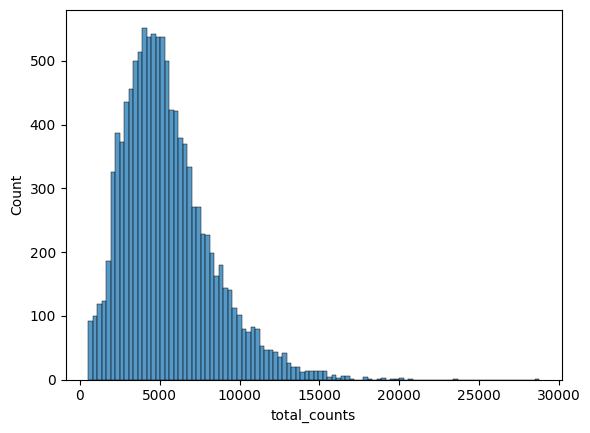

In [4]:
sns.histplot(adata.obs["total_counts"], bins=100, kde=False)

In [6]:
adata.obs[adata.obs['total_counts'] > 10000].shape

(807, 8)

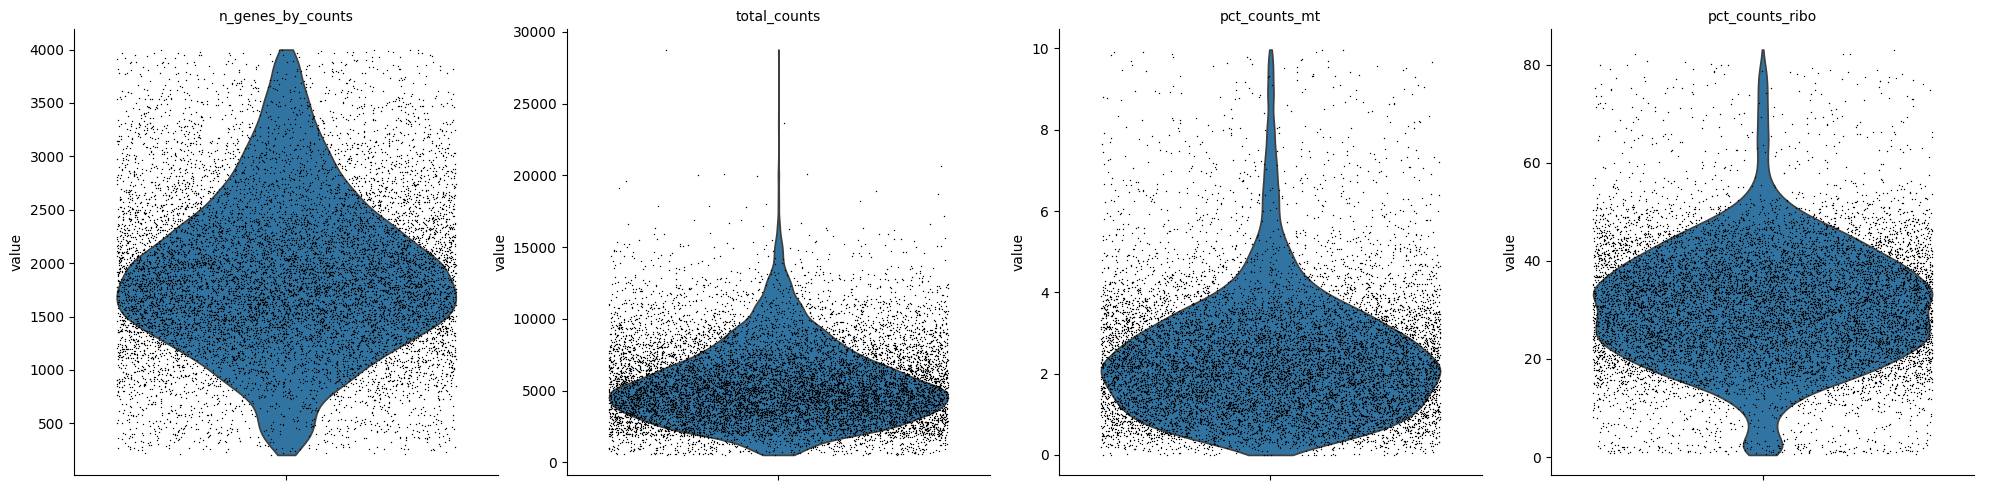

In [7]:
sc.pl.violin(adata, keys=["n_genes_by_counts", "total_counts", 
                          "pct_counts_mt", "pct_counts_ribo"], 
             jitter=0.4, multi_panel=True)

#### Normalisation and selecting variable genes

In [9]:
adata.layers['raw_counts'] = adata.X.copy()

In [10]:
adata

AnnData object with n_obs × n_vars = 11550 × 23755
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'doublet_score', 'predicted_doublet'
    var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'scrublet'
    layers: 'raw_counts'

In [13]:
adata.raw = adata

In [14]:
adata.raw

In [15]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata

AnnData object with n_obs × n_vars = 11550 × 23755
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'doublet_score', 'predicted_doublet'
    var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'scrublet', 'log1p'
    layers: 'raw_counts'

In [16]:
adata.uns['log1p']

{'base': None}

In [18]:
adata.X.toarray()[:5, :5]

array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]], dtype=float32)

In [19]:
adata.layers['raw_counts'].toarray()[:5,:5]

array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]], dtype=float32)

In [20]:
hvg_df = sc.pp.highly_variable_genes(adata, n_top_genes=2000, subset=True, flavor='seurat_v3', inplace=False)
hvg_df.head()

/home/sreeram/miniconda3/envs/scanpy_env/lib/python3.10/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)


,means,variances,gene_name,highly_variable_rank,variances_norm,highly_variable
LINC02593,0.000366,0.000421,LINC02593,1737.0,1.159269,True
TTLL10,0.000661,0.000973,TTLL10,426.0,1.348061,True
CFAP74,0.001092,0.001754,CFAP74,268.0,1.441075,True
TTC34,0.002647,0.003475,TTC34,1475.0,1.178502,True
PIK3CD-AS1,0.002041,0.002624,PIK3CD-AS1,1848.0,1.153237,True


In [21]:
adata

AnnData object with n_obs × n_vars = 11550 × 23755
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'doublet_score', 'predicted_doublet'
    var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'scrublet', 'log1p'
    layers: 'raw_counts'

In [22]:
hvg_df.shape

(2000, 6)

In [23]:
top10_hvgs = hvg_df.sort_values(by='highly_variable_rank').head(10)['gene_name'].to_list()

In [24]:
top10_hvgs

['S100A9',
 'FN1',
 'S100A8',
 'LYZ',
 'MT2A',
 'SPP1',
 'PRTN3',
 'CLC',
 'ELANE',
 'CXCL8']

/tmp/ipykernel_24857/2819247252.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


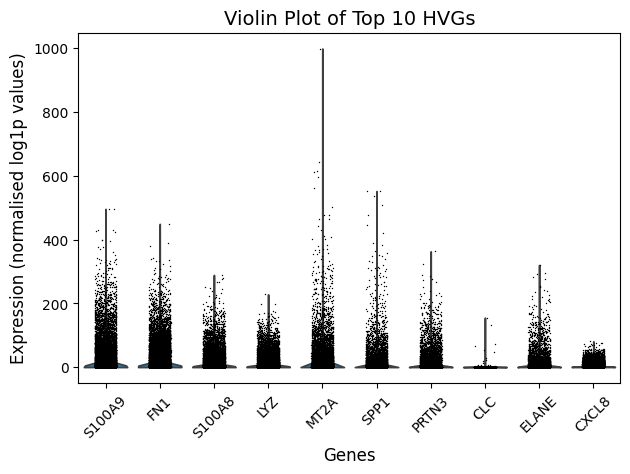

In [25]:
# Plot without immediately showing it
sc.pl.violin(
    adata=adata,
    keys=top10_hvgs,
    jitter=0.2,
    multi_panel=False,
    show=False
)

# Get current Axes
ax = plt.gca()

# Rotate x-axis labels
plt.xticks(rotation=45)

# Set axis labels
ax.set_xlabel("Genes", fontsize=12)
ax.set_ylabel("Expression (normalised log1p values)", fontsize=12)

# Set main title
ax.set_title("Violin Plot of Top 10 HVGs", fontsize=14)

# Show the plot
plt.tight_layout()
plt.show()

In [26]:
adata_hvg = adata[:, hvg_df['gene_name']].copy()
adata_hvg

AnnData object with n_obs × n_vars = 11550 × 2000
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'doublet_score', 'predicted_doublet'
    var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'scrublet', 'log1p'
    layers: 'raw_counts'

In [27]:
all(adata_hvg.var_names.isin(hvg_df['gene_name']))

True

In [28]:
sc.write(adata = adata_hvg, filename= 'sam1_hvg2k.h5ad', compression='gzip')

##### Dimensionality reduction

In [29]:
sc.pp.pca(adata_hvg, n_comps=50)

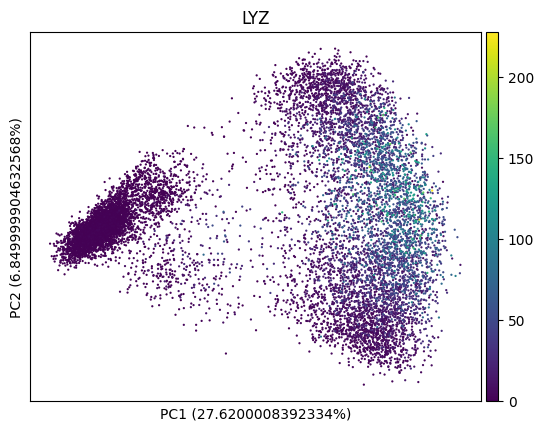

In [30]:
sc.pl.pca(adata_hvg, annotate_var_explained=True, color="LYZ")

Two well-separated clusters identified form the HVG gene LYZ

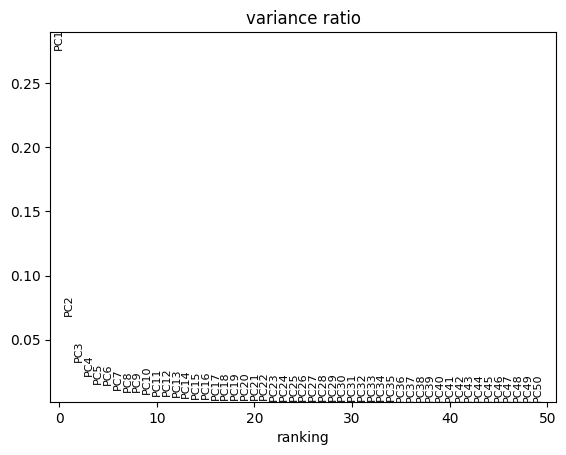

In [31]:
sc.pl.pca_variance_ratio(adata_hvg, n_pcs=50)

PC7-PC10 shows the knee point. Let's use PC10

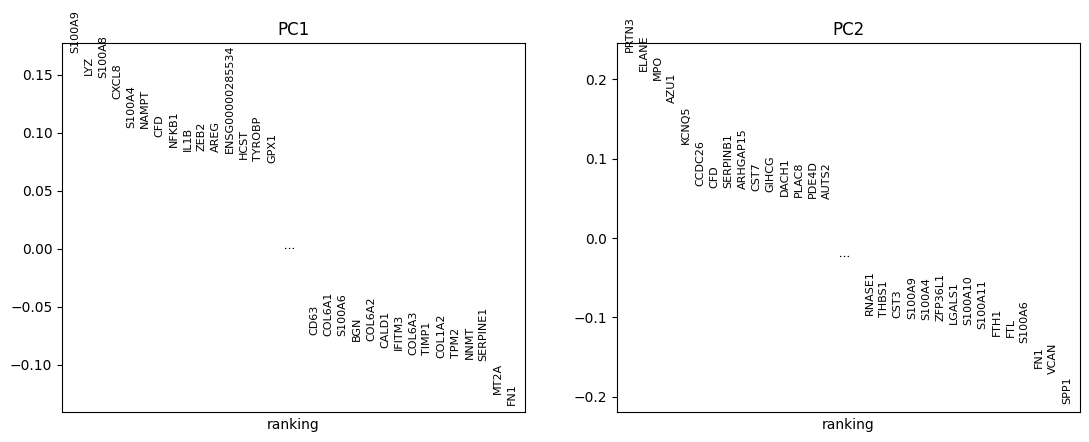

In [32]:
sc.pl.pca_loadings(adata_hvg, components=(1, 2), include_lowest=True)

In [33]:
sc.pp.neighbors(adata_hvg, n_neighbors=10, n_pcs=10)
adata_hvg

/home/sreeram/miniconda3/envs/scanpy_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AnnData object with n_obs × n_vars = 11550 × 2000
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'doublet_score', 'predicted_doublet'
    var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'scrublet', 'log1p', 'pca', 'neighbors'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'raw_counts'
    obsp: 'distances', 'connectivities'

In [34]:
sc.tl.umap(adata_hvg)

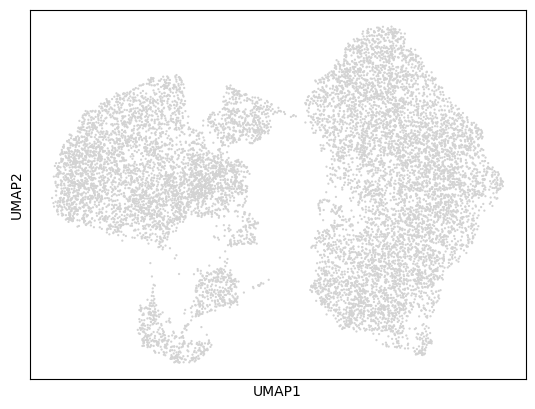

In [35]:
sc.pl.umap(adata_hvg)

In [36]:
# lets create groups based on QC violin plots and view them in UMAP
mt_cutoff = 5
ribo_cutoff = 25
n_genes_low = 2000

adata_hvg.obs['mt_group'] = np.where(adata_hvg.obs['pct_counts_mt'] < mt_cutoff, 'low_mt', 'high_mt')
adata_hvg.obs['ribo_group'] = np.where(adata_hvg.obs['pct_counts_ribo'] < ribo_cutoff, 'low_ribo', 'high_ribo')
adata_hvg.obs['n_genes_group'] = np.where(adata_hvg.obs['n_genes_by_counts'] < n_genes_low, 'low_n_genes', 'high_n_genes')
adata_hvg.obs.head()

,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,doublet_score,predicted_doublet,mt_group,ribo_group,n_genes_group
AAACCCAAGTCAACAA-1,1323,4218.0,49.0,1.161688,1628.0,38.596489,0.062652,False,low_mt,high_ribo,low_n_genes
AAACCCAAGTTAGAAC-1,2777,8030.0,207.0,2.577833,2175.0,27.085928,0.085420,False,low_mt,high_ribo,high_n_genes
AAACCCAAGTTGAATG-1,2197,9067.0,171.0,1.885960,3682.0,40.608803,0.048780,False,low_mt,high_ribo,high_n_genes
AAACCCAAGTTGGGAC-1,2289,6640.0,197.0,2.966867,2227.0,33.539158,0.043587,False,low_mt,high_ribo,high_n_genes
AAACCCACAACCGGAA-1,1793,8478.0,93.0,1.096957,4205.0,49.598961,0.043587,False,low_mt,high_ribo,low_n_genes


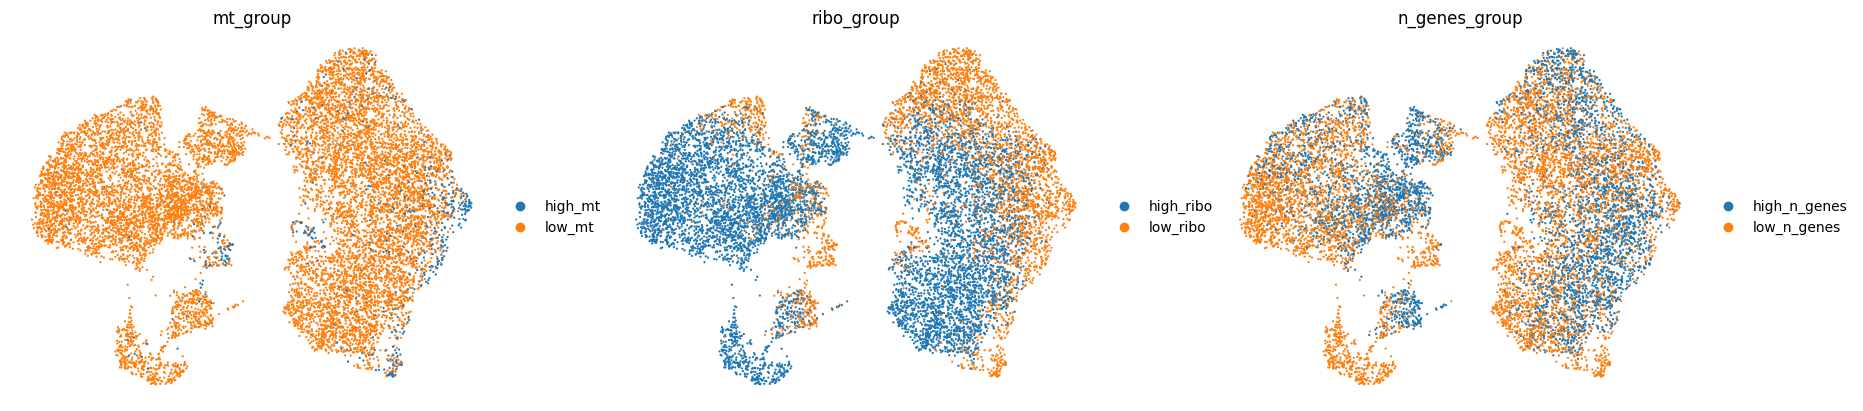

In [37]:
sc.pl.umap(
    adata_hvg,
    color=['mt_group', 'ribo_group', 'n_genes_group'],
    ncols=3,
    frameon=False
)

In [38]:
sc.write(adata=adata_hvg, filename='sam1_umap.h5ad', compression='gzip')

#### Clustering

In [39]:
adata_hvg

AnnData object with n_obs × n_vars = 11550 × 2000
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'doublet_score', 'predicted_doublet', 'mt_group', 'ribo_group', 'n_genes_group'
    var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'scrublet', 'log1p', 'pca', 'neighbors', 'umap', 'mt_group_colors', 'ribo_group_colors', 'n_genes_group_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'raw_counts'
    obsp: 'distances', 'connectivities'

In [40]:
sc.tl.leiden(adata=adata_hvg, resolution=0.5, random_state=198716, key_added='leiden_0.5')
sc.tl.leiden(adata=adata_hvg, resolution=1.0, random_state=198716, key_added='leiden_1.0')
sc.tl.leiden(adata=adata_hvg, resolution=2.0, random_state=198716, key_added='leiden_2.0')

/tmp/ipykernel_24857/2641350471.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata=adata_hvg, resolution=0.5, random_state=198716, key_added='leiden_0.5')


In [41]:
adata_hvg

AnnData object with n_obs × n_vars = 11550 × 2000
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'doublet_score', 'predicted_doublet', 'mt_group', 'ribo_group', 'n_genes_group', 'leiden_0.5', 'leiden_1.0', 'leiden_2.0'
    var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'scrublet', 'log1p', 'pca', 'neighbors', 'umap', 'mt_group_colors', 'ribo_group_colors', 'n_genes_group_colors', 'leiden_0.5', 'leiden_1.0', 'leiden_2.0'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'raw_counts'
    obsp: 'distances', 'connectivities'

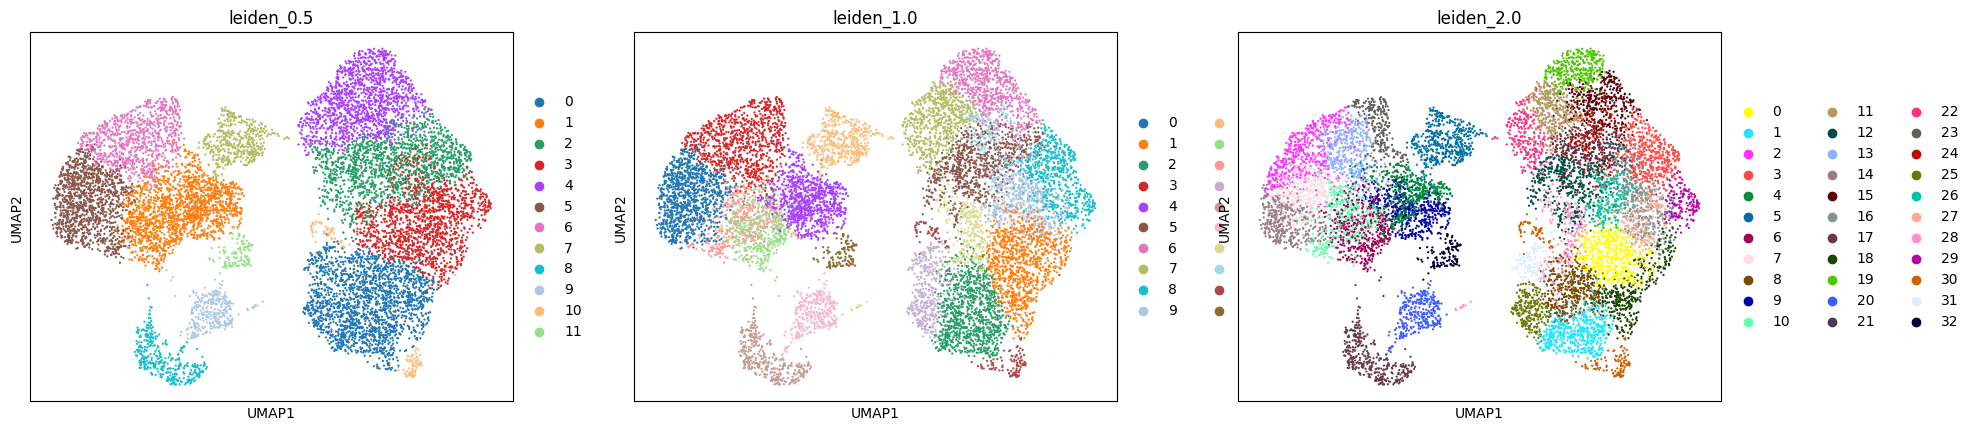

In [42]:
sc.pl.umap(adata_hvg, color=['leiden_0.5', 'leiden_1.0', 'leiden_2.0'])

Higher the resolution, more number of clusters. How to choose ?!!!

Statistical methods - ARI, NMI

Biological - cell types and differentially expressed genes 

In [44]:
sc.tl.rank_genes_groups(adata_hvg, "leiden_0.5", method="t-test", use_raw=False)

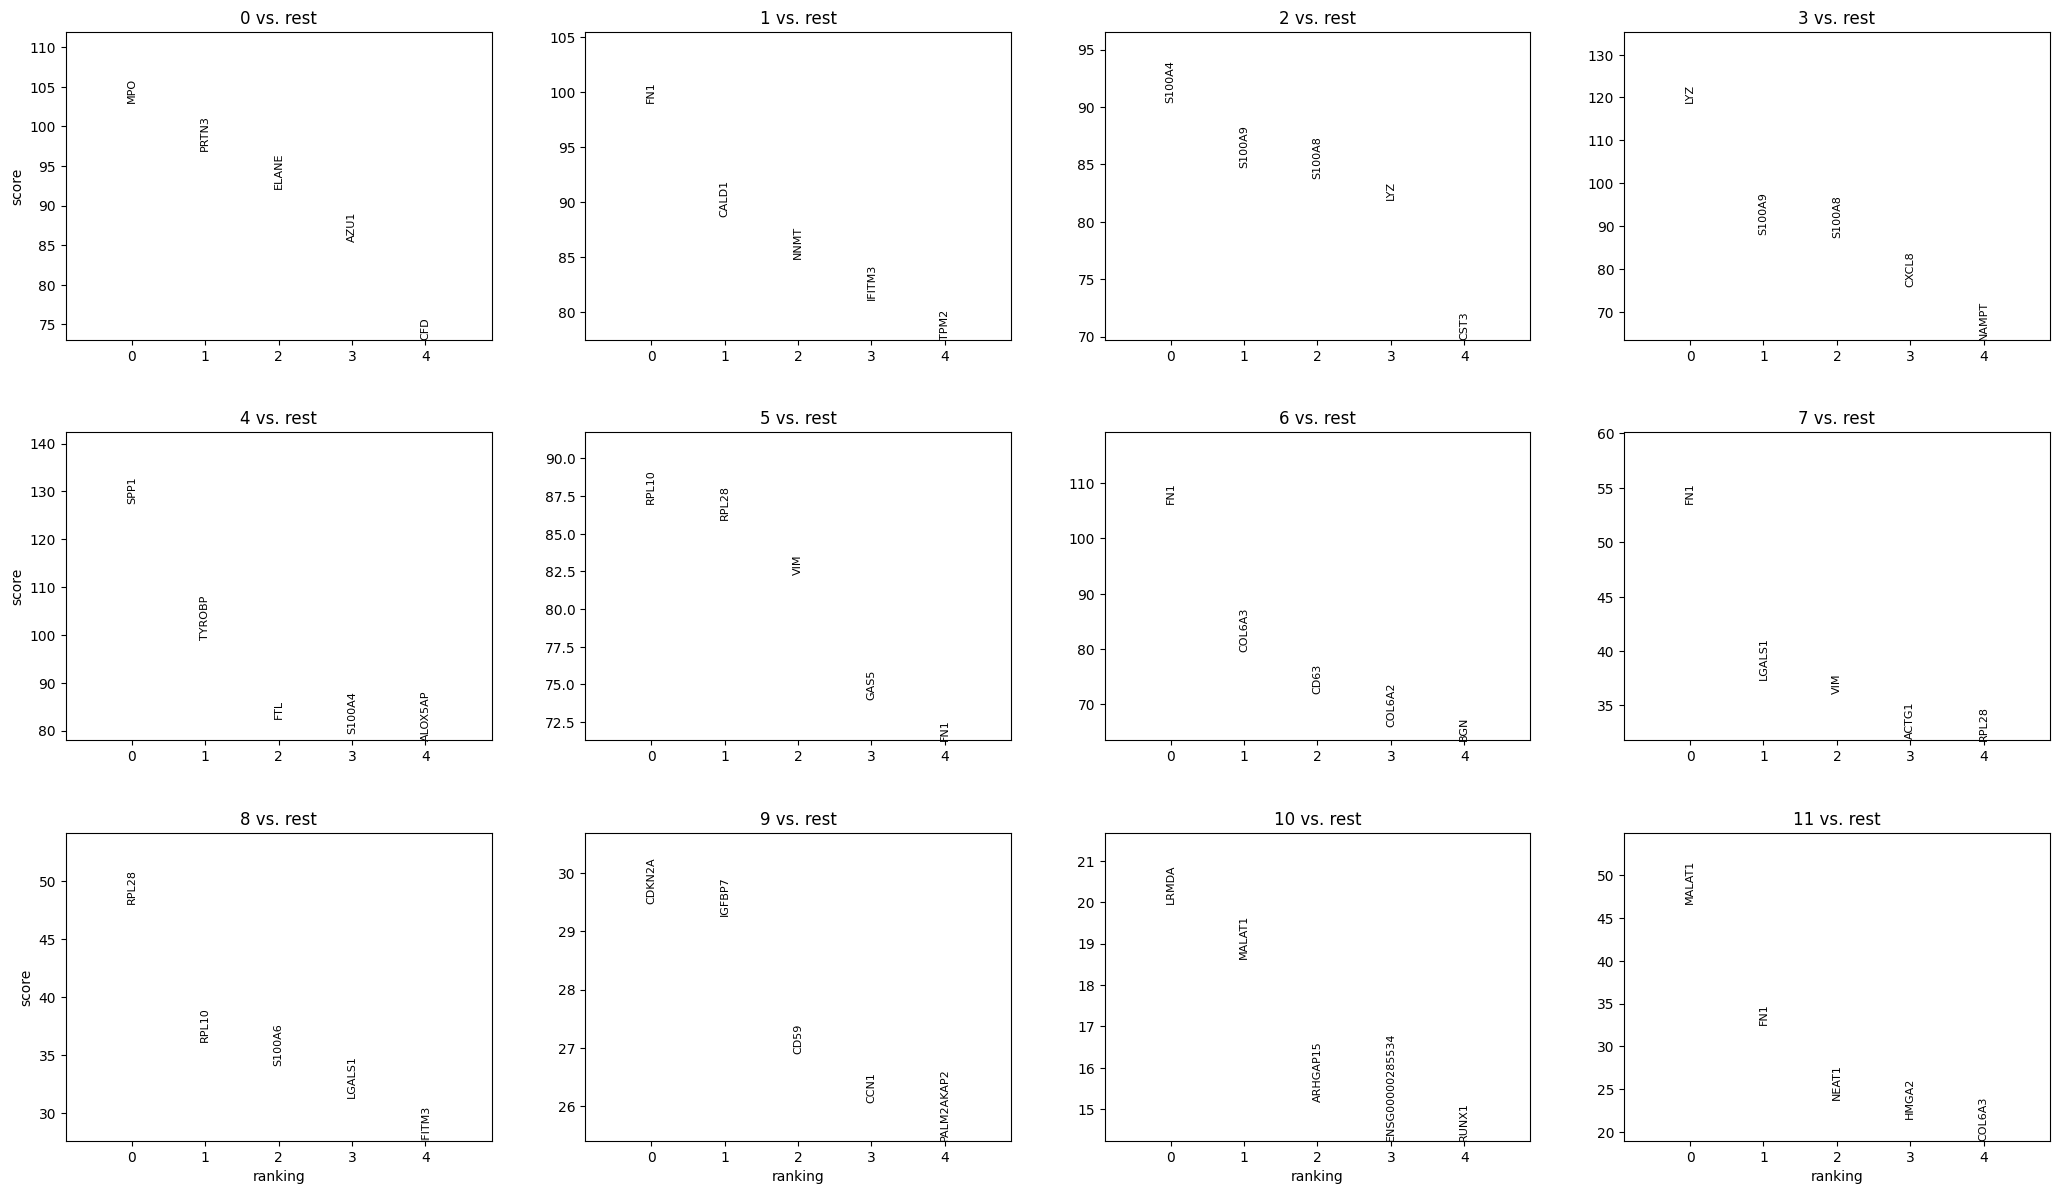

In [45]:
sc.pl.rank_genes_groups(adata_hvg, n_genes=5, sharey=False)

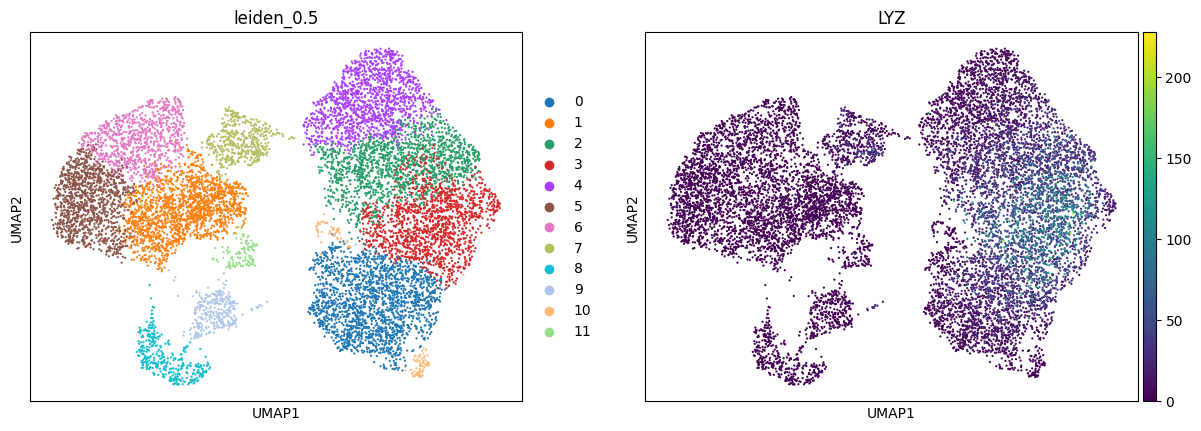

In [46]:
sc.pl.umap(adata_hvg, color=['leiden_0.5', 'LYZ'])

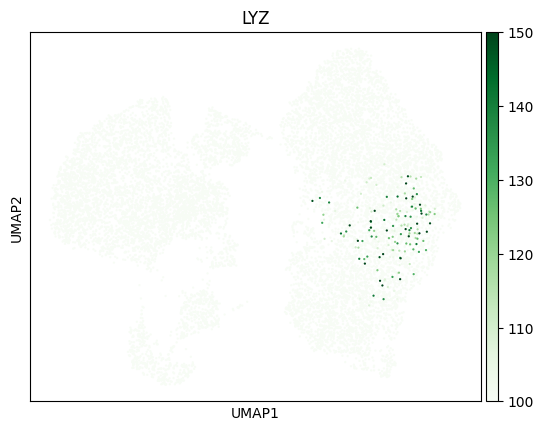

In [47]:
sc.pl.umap(
    adata_hvg,
    color="LYZ",
    vmin=100,          # everything below this looks the same
    vmax=150,          # cap high values
    cmap="Greens"
)

In [48]:
# Convert rank_genes_groups to a dataframe
rank_df = sc.get.rank_genes_groups_df(adata_hvg, None)

# Get top 5 genes per cluster
top5 = (
    rank_df.groupby("group")
           .head(5)
           .sort_values(["group", "logfoldchanges"], ascending=[True, False])
)

top5_genes = top5["names"].unique().tolist()
top5_genes

/tmp/ipykernel_24857/899141795.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rank_df.groupby("group")


['PRTN3',
 'ELANE',
 'MPO',
 'AZU1',
 'CFD',
 'NNMT',
 'FN1',
 'CALD1',
 'TPM2',
 'IFITM3',
 'S100A9',
 'S100A8',
 'LYZ',
 'S100A4',
 'CST3',
 'CXCL8',
 'NAMPT',
 'SPP1',
 'ALOX5AP',
 'TYROBP',
 'FTL',
 'GAS5',
 'VIM',
 'RPL28',
 'RPL10',
 'COL6A3',
 'COL6A2',
 'BGN',
 'CD63',
 'LGALS1',
 'ACTG1',
 'S100A6',
 'CDKN2A',
 'PALM2AKAP2',
 'CCN1',
 'IGFBP7',
 'CD59',
 'ARHGAP15',
 'LRMDA',
 'ENSG00000285534',
 'RUNX1',
 'MALAT1',
 'HMGA2',
 'NEAT1']

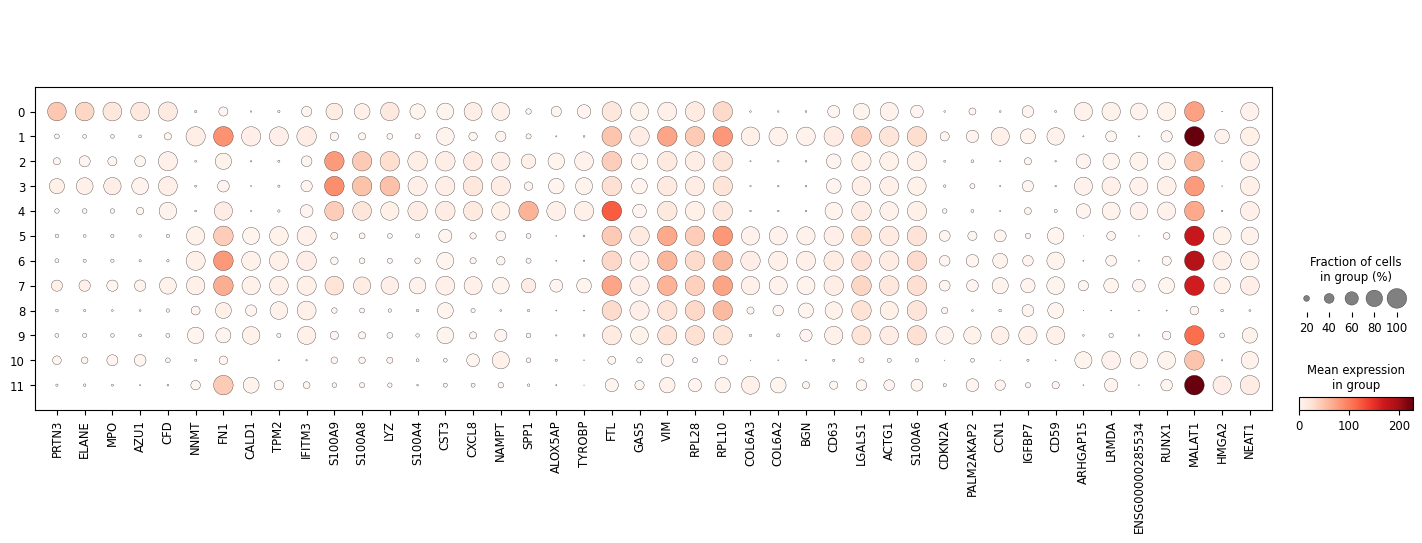

In [49]:
sc.pl.dotplot(adata_hvg, var_names=top5_genes, groupby="leiden_0.5")

In [50]:
sc.write(adata=adata_hvg, filename='sam1_clustering.h5ad')